In [2]:
import torch
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer

# from transformers_sae import _autoreload
from transformers_sae.ops import MemoryTrackingMode
from transformers_sae.replacement_model import GemmaReplacement, make_replacement_model

# Tweak TRAINING_BATCH_SIZE for your hardware if necessary
if torch.cuda.is_available():
    TRAINING_DEVICE = "cuda:0"
    TRAINING_BATCH_SIZE = 2
elif torch.mps.is_available():
    TRAINING_DEVICE = "mps:0"
    TRAINING_BATCH_SIZE = 2
else:
    TRAINING_DEVICE = "cpu"
    TRAINING_BATCH_SIZE = 2

model_id = "google/gemma-2-2b"
tokenizer = AutoTokenizer.from_pretrained(model_id)
training_dataset = load_dataset(
    "monology/pile-uncopyrighted-parquet",
    split="train",
    streaming=True,
    columns=["text"],
)
validation_dataset = load_dataset(
    "monology/pile-test-val",
    split="validation",
    revision="refs/convert/parquet",
    streaming=True,
    columns=["text"],
)

with MemoryTrackingMode() as mtm:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map=TRAINING_DEVICE,
        dtype=torch.bfloat16,
        use_safetensors=True,
    )
    model = make_replacement_model(
        model,
        {},
        num_layers=model.config.num_hidden_layers,
        context_length=1024,  # model.config.max_position_embeddings,
        d_model=model.config.hidden_size,
        layer_path="model.layers",
        replacement_class=GemmaReplacement,
    )
    model.eval()
    model.requires_grad_(False)

print(model)
print(mtm.memory_max)
print(mtm.memory_cur)

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1987 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

GemmaReplacementInstance(
  (model): Gemma2Model(
    (embed_tokens): Embedding(256000, 2304, padding_idx=0)
    (layers): ModuleList(
      (0-25): 26 x Gemma2DecoderLayer(
        (self_attn): Gemma2Attention(
          (q_proj): Linear(in_features=2304, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2304, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2304, bias=False)
        )
        (mlp): Gemma2MLP(
          (gate_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (up_proj): Linear(in_features=2304, out_features=9216, bias=False)
          (down_proj): Linear(in_features=9216, out_features=2304, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (post_attention_layernorm): Gemma2RMSNorm((2304,), eps=1e-06)
        (pre_feedforward_layernorm): Gemm

In [3]:
TRAINING_CACHE_DIR = None if torch.cuda.is_available() else ".training_cache"
VALIDATION_CACHE_DIR = None if torch.cuda.is_available() else ".validation_cache"
NUM_TRAINING_TOKENS = int(1e7) if torch.cuda.is_available() else int(1e6)
EVAL_INTERVAL = int(1e5)
NUM_VALIDATION_TOKENS = int(1e6) if torch.cuda.is_available() else int(1e5)
# to match Gemma Scope
D_SAE = 16384
TOPK = 100
TOKENIZER_BATCH_SIZE = 128
FINETUNE_FRACTION = 0.1
# Note this will use up ~1.8GB of space, set to False if you want to skip
SAVE_FINAL_RESULTS = True

In [4]:
from concurrent.futures import ThreadPoolExecutor
from transformers_sae.ops import find_latest_checkpoint, load_checkpoint

checkpoint_dir = "/workspace/sae_checkpoints/gemma_2_2b/next_layer_finetuned_interaction/"

saes = {}

def load_layer_checkpoint(layer):
    checkpoint = find_latest_checkpoint(checkpoint_dir, layer)
    if checkpoint is not None:
        sae = load_checkpoint(checkpoint).sae
        sae.eval()
        sae.onload()
        print(f"Loaded checkpoint for layer {layer}")
        return layer, sae
    else:
        print(f"No checkpoint found for layer {layer}")
        return layer, None

# Load the latest checkpoints for each layer in parallel
with ThreadPoolExecutor() as executor:
    results = executor.map(load_layer_checkpoint, range(model.num_layers - 1, -1, -1))
    for layer, sae in results:
        if sae is not None:
            saes[layer] = sae


Loaded checkpoint for layer 23
Loaded checkpoint for layer 8
Loaded checkpoint for layer 22
Loaded checkpoint for layer 7
Loaded checkpoint for layer 10
Loaded checkpoint for layer 0
Loaded checkpoint for layer 21
Loaded checkpoint for layer 17
Loaded checkpoint for layer 24
Loaded checkpoint for layer 4
Loaded checkpoint for layer 15
Loaded checkpoint for layer 14
Loaded checkpoint for layer 25
Loaded checkpoint for layer 18
Loaded checkpoint for layer 16
Loaded checkpoint for layer 12
Loaded checkpoint for layer 13
Loaded checkpoint for layer 9
Loaded checkpoint for layer 6
Loaded checkpoint for layer 20
Loaded checkpoint for layer 5
Loaded checkpoint for layer 3
Loaded checkpoint for layer 19
Loaded checkpoint for layer 11
Loaded checkpoint for layer 1
Loaded checkpoint for layer 2


In [5]:
import numpy as np

from transformers_sae.validation import run_validations

validations = {}
geom_kl = {}

for start_layer in range(0, model.num_layers):
    print(f"Running validations for replacement starting at {start_layer}")
    validations[start_layer] = run_validations(
        model,
        tokenizer,
        saes,
        validation_dataset,
        TOKENIZER_BATCH_SIZE,
        1,# TRAINING_BATCH_SIZE,
        NUM_VALIDATION_TOKENS,
        cache_dir=VALIDATION_CACHE_DIR,
        start_layer=start_layer,
        # eval_layers=[start_layer, model.num_layers],
    )
    geom_kl[start_layer] = np.exp(
        np.mean(
            np.log(np.clip(validations[start_layer].layer_results[model.num_layers].kl, min=1e-9))
        )
    ).item()
    print(geom_kl[start_layer])


Running validations for replacement starting at 0


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.2845982313156128
Running validations for replacement starting at 1


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.28670066595077515
Running validations for replacement starting at 2


...

0.0075016445480287075
Running validations for replacement starting at 24


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.00549571355804801
Running validations for replacement starting at 25


Running SAE evals:   0%|          | 0/1000000 [00:00<?, ?it/s]

0.004388933535665274


In [6]:
from transformers_sae.ops import save_validations

save_validations(validations, "/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_finetuned_interaction/")

In [9]:
from transformers_sae.ops import load_validations
gemma_scope_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/gemma_scope/")
next_layer_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_old/")
next_layer_finetuned_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_finetuned_old/")
next_layer_interaction_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_interaction/")
next_layer_finetuned_interaction_validations = load_validations("/workspace/sae_checkpoints/validations/gemma_2_2b/next_layer_finetuned_interaction/")
gemma_scope_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in gemma_scope_validations.items()
}
next_layer_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in next_layer_validations.items()
}
next_layer_finetuned_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in next_layer_finetuned_validations.items()
}
next_layer_interaction_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in next_layer_interaction_validations.items()
}
next_layer_finetuned_interaction_kl = {
    layer: np.exp(
        np.mean(np.log(np.clip(v.layer_results[model.num_layers].kl, min=1e-9)))
    ).item()
    for layer, v in next_layer_finetuned_interaction_validations.items()
}

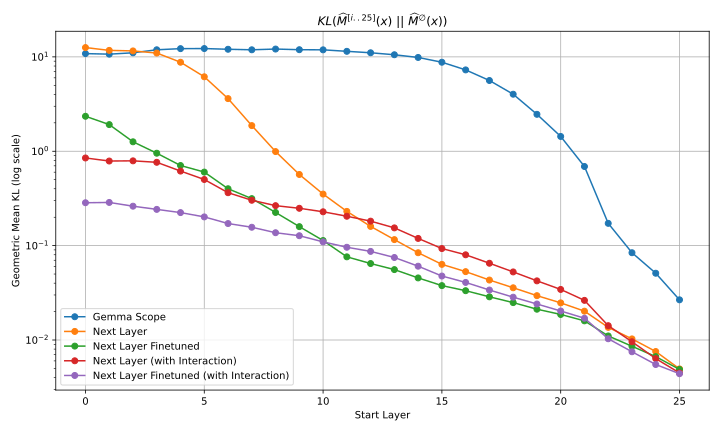

In [ ]:
import matplotlib.pyplot as plt
from transformers_sae.ops import current_plot_to_svg

layers = sorted(gemma_scope_kl.keys())
plt.figure(figsize=(10, 6))
plt.plot(
    layers, [gemma_scope_kl[layer] for layer in layers], marker="o", label="Gemma Scope"
)
plt.plot(
    layers, [next_layer_kl[layer] for layer in layers], marker="o", label="Next Layer"
)
plt.plot(
    layers,
    [next_layer_finetuned_kl[layer] for layer in layers],
    marker="o",
    label="Next Layer Finetuned",
)
plt.plot(
    layers,
    [next_layer_interaction_kl[layer] for layer in layers],
    marker="o",
    label="Next Layer (with Interaction)",
)
plt.plot(
    layers,
    [next_layer_finetuned_interaction_kl[layer] for layer in layers],
    marker="o",
    label="Next Layer Finetuned (with Interaction)",
)
plt.xlabel("Start Layer")
plt.ylabel("Geometric Mean KL (log scale)")
plt.yscale("log")
plt.title("$KL(\\widehat{{M}}^{{[i..25]}}(x)\\ ||\\ \\widehat{{M}}^{{\\emptyset}}(x))$")
plt.grid(True)
plt.legend()
plt.tight_layout()

current_plot_to_svg("replacement_kl", ".plots")


In [ ]:
from transformers_sae.sae_lens_wrapper import wrap_sae_lens_pretrained

gemma_scope = {}

for layer in range(0, model.num_layers):
    gemma_scope[layer] = wrap_sae_lens_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=TRAINING_DEVICE,
    )